# Red Neuronal Recurrente RNN

In [30]:
# 📦 LIBRERÍAS
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# 📂 CARGAR DATOS
ruta = r'C:\docs\DOCTORADO\Machine_Learning\tornados.csv'
df = pd.read_csv(ruta)

In [31]:
# 🧹 PREPROCESAMIENTO COMP
df_rnn = df.copy()

# Eliminar columnas no útiles o que están relacionadas con la variable objetivo
df_rnn.drop(['om', 'date', 'time', 'datetime_utc', 'stf', 'f1', 'f2', 'f3', 'f4', 'fat'], axis=1, inplace=True)

# Eliminar filas sin 'inj'
df_rnn.dropna(subset=['inj'], inplace=True)

# Convertir columnas a tipo adecuado
df_rnn['fc'] = df_rnn['fc'].astype(int)

# Codificar variables categóricas
df_rnn = pd.get_dummies(df_rnn, columns=['st', 'tz'], drop_first=True)

# Separar variables
X = df_rnn.drop('inj', axis=1)
y = df_rnn['inj']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [32]:
# Imputación de NaN con la media
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape para RNN
X_train_rnn = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_rnn = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [33]:
# 🧠 MODELO RNN
model_rnn = Sequential()
model_rnn.add(SimpleRNN(32, activation='relu', input_shape=(1, X_train_scaled.shape[1])))
model_rnn.add(Dense(1))
model_rnn.compile(optimizer='adam', loss='mse')

In [34]:
import time
start_rnn = time.time()

# ENTRENAR
model_rnn.fit(X_train_rnn, y_train, epochs=10, batch_size=32, verbose=1)

end_rnn = time.time()

# Guardar duración
tiempo_rnn = end_rnn - start_rnn

Epoch 1/10
1503/1503 [==============================] - 5s 3ms/step - loss: 260.3452
Epoch 2/10
1503/1503 [==============================] - 4s 3ms/step - loss: 234.3189
Epoch 3/10
1503/1503 [==============================] - 4s 3ms/step - loss: 214.0703
Epoch 4/10
1503/1503 [==============================] - 4s 3ms/step - loss: 199.3879
Epoch 5/10
1503/1503 [==============================] - 4s 3ms/step - loss: 191.3538
Epoch 6/10
1503/1503 [==============================] - 4s 3ms/step - loss: 185.5408
Epoch 7/10
1503/1503 [==============================] - 4s 3ms/step - loss: 183.2352
Epoch 8/10
1503/1503 [==============================] - 4s 3ms/step - loss: 180.8228
Epoch 9/10
1503/1503 [==============================] - 4s 3ms/step - loss: 178.9393
Epoch 10/10
1503/1503 [==============================] - 4s 3ms/step - loss: 177.6335


In [35]:
# 📈 PREDICCIONES Y MÉTRICAS
y_pred_rnn = model_rnn.predict(X_test_rnn).flatten()

# Alinear índices si es necesario
y_test = y_test.reset_index(drop=True)

mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
rmse_rnn = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
r2_rnn = r2_score(y_test, y_pred_rnn)

print("MAE:", mae_rnn)
print("RMSE:", rmse_rnn)
print("R2:", r2_rnn)

644/644 [==============================] - 1s 1ms/step
MAE: 2.538907051086426
RMSE: 16.48390568792832
R2: 0.3602442145347595


In [36]:
resultados_rnn = pd.DataFrame({
    'Modelo': ['RNN simple (1 capa, relu)'],
    'MAE': [round(mae_rnn, 2)],
    'RMSE': [round(rmse_rnn, 2)],
    'R²': [round(r2_rnn, 4)],
    'CPU time (s)': [round(tiempo_rnn, 4)]
})

# Mostrar resultados
display(resultados_rnn)

# Guardar por si necesitas usarlo después
resultados_rnn.to_csv("resultados_rnn", index=False)

,Modelo,MAE,RMSE,R²,CPU time (s)
0,"RNN simple (1 capa, relu)",2.54,16.48,0.3602,44.6069


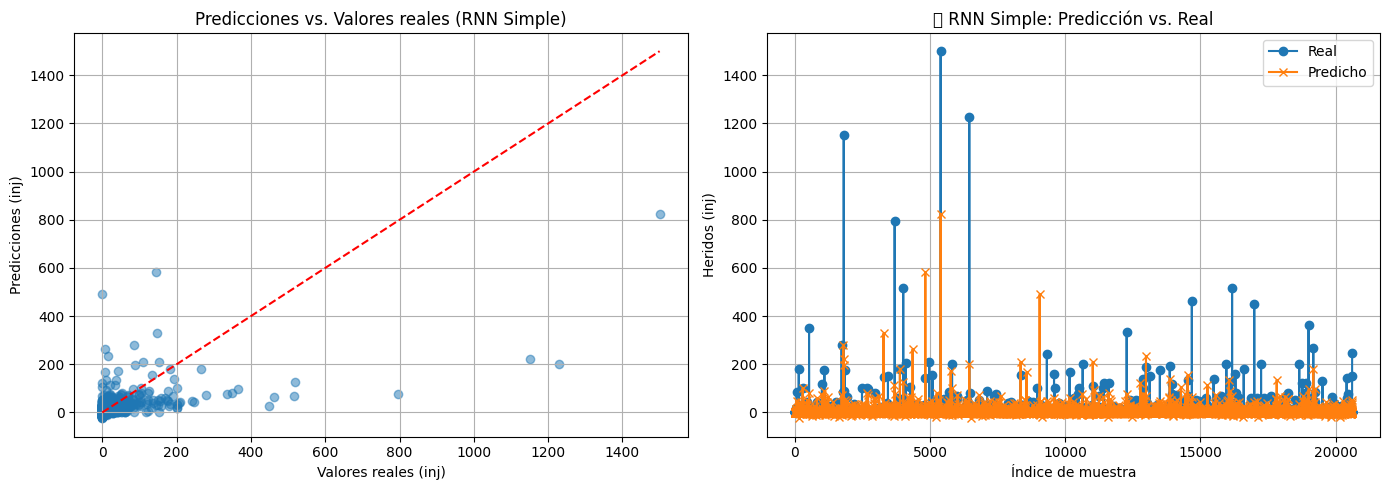

In [37]:
import matplotlib.pyplot as plt

# Crear figura con 2 subplots en fila
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 🔹 Gráfico 1: Scatter Pred vs Real
axes[0].scatter(y_test, y_pred_rnn, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Valores reales (inj)')
axes[0].set_ylabel('Predicciones (inj)')
axes[0].set_title('Predicciones vs. Valores reales (RNN Simple)')
axes[0].grid(True)

# 🔹 Gráfico 2: Línea Pred vs Real
axes[1].plot(y_test.values, label='Real', marker='o')
axes[1].plot(y_pred_rnn, label='Predicho', marker='x')
axes[1].set_title("🔁 RNN Simple: Predicción vs. Real")
axes[1].set_xlabel("Índice de muestra")
axes[1].set_ylabel("Heridos (inj)")
axes[1].legend()
axes[1].grid(True)

# Ajustar diseño
plt.tight_layout()
plt.show()


## Optimización del Modelo RNN con 200 épocas

In [38]:
from tensorflow.keras.callbacks import EarlyStopping

# Crear el modelo RNN
model_rnn = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    Dense(32, activation='relu'),
    Dense(1)  # salida para regresión
])

model_rnn.compile(optimizer='adam', loss='mse')

# Definir EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,            # si no mejora por 10 épocas seguidas, se detiene
    restore_best_weights=True
)

import time
start_rnn = time.time()


# Entrenar con validación
history_rnn = model_rnn.fit(
    X_train_rnn,
    y_train,
    validation_split=0.2,   # usa el 20% del entrenamiento para validar
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

end_rnn = time.time()
# Guardar duración
tiempo_rnn_opt = end_rnn - start_rnn

Epoch 1/200
1203/1203 [==============================] - 5s 4ms/step - loss: 228.3871 - val_loss: 384.7119
Epoch 2/200
1203/1203 [==============================] - 4s 4ms/step - loss: 188.2222 - val_loss: 355.3587
Epoch 3/200
1203/1203 [==============================] - 4s 4ms/step - loss: 167.0994 - val_loss: 340.9467
Epoch 4/200
1203/1203 [==============================] - 4s 4ms/step - loss: 152.5335 - val_loss: 329.5200
Epoch 5/200
1203/1203 [==============================] - 4s 4ms/step - loss: 142.8109 - val_loss: 333.7691
Epoch 6/200
1203/1203 [==============================] - 4s 4ms/step - loss: 131.4936 - val_loss: 318.0922
Epoch 7/200
1203/1203 [==============================] - 4s 4ms/step - loss: 124.6898 - val_loss: 326.6923
Epoch 8/200
1203/1203 [==============================] - 4s 4ms/step - loss: 123.0812 - val_loss: 318.9562
Epoch 9/200
1203/1203 [==============================] - 4s 4ms/step - loss: 113.8091 - val_loss: 324.3057
Epoch 10/200
1203/1203 [=============

In [39]:
# Predicción y métricas
y_pred_rnn = model_rnn.predict(X_test_rnn).flatten()

mae_rnn_opt = mean_absolute_error(y_test, y_pred_rnn)
rmse_rnn_opt = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
r2_rnn_opt = r2_score(y_test, y_pred_rnn)

print(f"MAE: {mae_rnn:.2f}")
print(f"RMSE: {rmse_rnn:.2f}")
print(f"R2: {r2_rnn:.2f}")


644/644 [==============================] - 1s 1ms/step
MAE: 2.54
RMSE: 16.48
R2: 0.36


In [40]:

resultados_rnn_opt = pd.DataFrame({
    'Modelo': ['RNN optimizado'],
    'MAE': [round(mae_rnn_opt, 2)],
    'RMSE': [round(rmse_rnn_opt, 2)],
    'R²': [round(r2_rnn_opt, 4)],
    'CPU time (s)': [round(tiempo_rnn_opt, 4)]
})

# Mostrar resultados
display(resultados_rnn_opt)

# Guardar
resultados_rnn_opt.to_csv("resultados_rnn_opt.csv", index=False)


,Modelo,MAE,RMSE,R²,CPU time (s)
0,RNN optimizado,1.85,17.07,0.314,69.7488


644/644 [==============================] - 1s 1ms/step


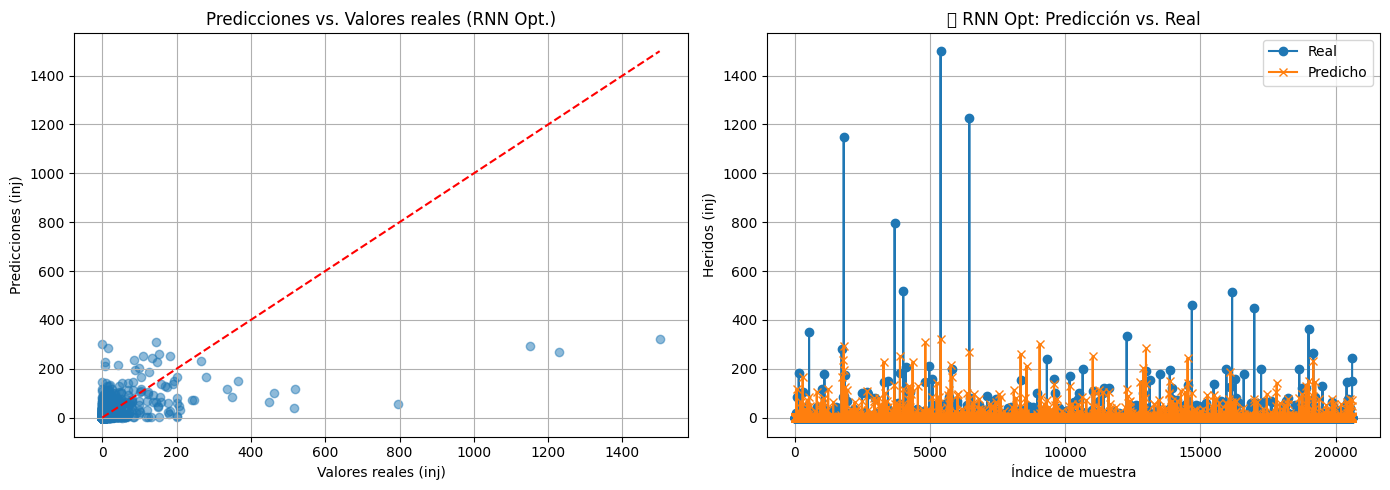

In [41]:
import matplotlib.pyplot as plt

y_pred_rnn_opt = model_rnn.predict(X_test_rnn).flatten()


# Crear una figura con 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 🔹 Gráfico 1: Scatter Pred vs Real
axes[0].scatter(y_test, y_pred_rnn_opt, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Valores reales (inj)')
axes[0].set_ylabel('Predicciones (inj)')
axes[0].set_title('Predicciones vs. Valores reales (RNN Opt.)')
axes[0].grid(True)

# 🔹 Gráfico 2: Línea Pred vs Real
axes[1].plot(y_test.values, label='Real', marker='o')
axes[1].plot(y_pred_rnn_opt, label='Predicho', marker='x')
axes[1].set_title("🔁 RNN Opt: Predicción vs. Real")
axes[1].set_xlabel("Índice de muestra")
axes[1].set_ylabel("Heridos (inj)")
axes[1].legend()
axes[1].grid(True)

# Ajustar diseño
plt.tight_layout()
plt.show()



## Aplicación de Pipeline y Gridsearch

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping
import time
import glob
from joblib import dump, load

In [56]:
# ⚙️ Función para construir el modelo RNN
def create_rnn_model(units=32):
    model = Sequential([
        SimpleRNN(units, activation='tanh', input_shape=(1, X_train.shape[1])),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model  # ← correctamente indentado

# 📦 Imports
from sklearn.model_selection import GridSearchCV
import time


In [64]:


# 🧪 Pipeline: escalar, reshape, modelo

def create_rnn_model(units=32):
    model = Sequential()
    model.add(SimpleRNN(units, activation='tanh', input_shape=(1, X_train.shape[1])))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

start = time.process_time()
grid = GridSearchCV(pipe, param_grid, cv=3, scoring='r2', n_jobs=1)
grid.fit(X_train, y_train)
end = time.process_time()

tiempo_rnn_grid = end - start

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("reshape", FunctionTransformer(lambda x: x.reshape(x.shape[0], 1, x.shape[1]), validate=False)),
    ("model", KerasRegressor(build_fn=create_rnn_model, verbose=0))

])

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import GridSearchCV
import time

# ⚙️ Función para construir el modelo RNN
def create_rnn_model(units=32):
    model = Sequential()
    model.add(SimpleRNN(units, activation='tanh', input_shape=(1, X_train.shape[1])))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# 📦 Definir el pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("reshape", FunctionTransformer(lambda x: x.reshape(x.shape[0], 1, x.shape[1]), validate=False)),
    ("model", KerasRegressor(build_fn=create_rnn_model, verbose=0))
])

# 🔧 Definir el grid de parámetros
param_grid = {
    'model__units': [16, 32],
    'model__batch_size': [32],
    'model__epochs': [10]
}

# 🔁 Entrenamiento con GridSearchCV
start = time.process_time()
grid = GridSearchCV(pipe, param_grid, cv=3, scoring='r2', n_jobs=1)
grid.fit(X_train, y_train)
end = time.process_time()

tiempo_rnn_grid = end - start


In [61]:
print("Best R² score:", round(grid.best_score_, 4))
print("Mejores parámetros:", grid.best_params_)


Best R² score: 0.1771
Mejores parámetros: {'model__batch_size': 32, 'model__epochs': 10, 'model__units': 32}


In [62]:
# 🧮 Evaluar sobre el test set
y_pred_rnn_grid = grid.predict(X_test)

mae_rnn_grid = mean_absolute_error(y_test, y_pred_rnn_grid)
rmse_rnn_grid = np.sqrt(mean_squared_error(y_test, y_pred_rnn_grid))
r2_rnn_grid = r2_score(y_test, y_pred_rnn_grid)

# 📊 Guardar en DataFrame
resultados_rnn_grid = pd.DataFrame({
    'Modelo': ['RNN_PG (Pipeline + GridSearch)'],
    'MAE': [round(mae_rnn_grid, 2)],
    'RMSE': [round(rmse_rnn_grid, 2)],
    'R²': [round(r2_rnn_grid, 4)],
    'CPU time (s)': [round(tiempo_rnn_grid, 2)]
})

display(resultados_rnn_grid)
resultados_rnn_grid.to_csv("resultados_rnn_grid.csv", index=False)

,Modelo,MAE,RMSE,R²,CPU time (s)
0,RNN_PG (Pipeline + GridSearch),1.98,18.77,0.1707,291.94


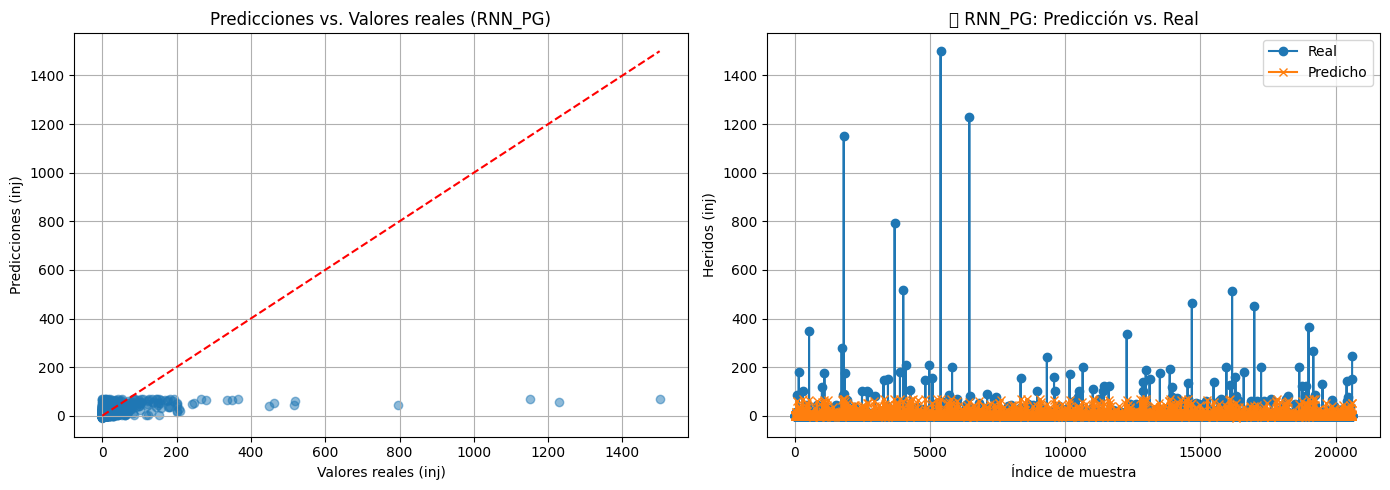

In [66]:
import matplotlib.pyplot as plt

# 🖼️ Crear figura y subgráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 🔹 Gráfico 1: Dispersión (scatter)
axes[0].scatter(y_test, y_pred_rnn_grid, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Valores reales (inj)')
axes[0].set_ylabel('Predicciones (inj)')
axes[0].set_title('Predicciones vs. Valores reales (RNN_PG)')
axes[0].grid(True)

# 🔹 Gráfico 2: Línea Real vs Predicho
axes[1].plot(y_test.values, label='Real', marker='o')
axes[1].plot(y_pred_rnn_grid, label='Predicho', marker='x')
axes[1].set_title("🔁 RNN_PG: Predicción vs. Real")
axes[1].set_xlabel("Índice de muestra")
axes[1].set_ylabel("Heridos (inj)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
